# Week 12: Object Detection — From R-CNN to YOLO
## Course: Digital Health and AI in Medical Applications (BME 7451)
### Instructor: Prof. Che-Wei Lin, NCKU BME

---

**Learning Objectives:**
1. Distinguish classification, localization, and detection tasks in medical imaging (Understand)
2. Explain the evolution from R-CNN to Faster R-CNN and the two-stage paradigm (Understand)
3. Describe YOLO's single-stage approach and why it enables real-time clinical AI (Analyze)
4. Compute IoU, mAP, and interpret precision-recall curves for detection (Apply)
5. Run YOLOv8 inference on medical images using the Ultralytics library (Apply)

**Tools:** Google Colab + Gemini AI
**Libraries:** ultralytics, numpy, pandas, matplotlib, torch, torchvision, PIL, sklearn
**Dataset:** Synthetic medical detection data + COCO pretrained model for inference
**Estimated Time:** 45-55 minutes
**GPU:** Recommended (required for Sections 4-7). Set Runtime > Change runtime type > GPU.

---

### Red Thread: The Missed Polyp

> A 58-year-old patient lies on the endoscopy table for a routine colonoscopy.
> The gastroenterologist carefully advances the scope — but even the best
> endoscopists miss **22-28% of polyps**. Flat polyps, hidden behind folds,
> obscured by mucus. Each missed polyp is a potential colorectal cancer left
> to grow for 3-10 years until the next screening.
>
> Now imagine an AI overlay on the endoscopy monitor — a real-time bounding
> box appears around every suspicious polyp, like a self-driving car marking
> pedestrians. Clinical trials show this cuts the miss rate to **7%**. That's
> thousands of cancers caught early.
>
> **Today, every algorithm and metric connects back to ONE question: How does
> this help the AI draw a box around the polyp the doctor almost missed?**


## 0. Environment Setup

Install the Ultralytics library (provides YOLOv8) and import all required
packages. We also verify GPU availability — object detection models benefit
significantly from GPU acceleration.

**Important:** In Colab, set your runtime to **GPU** before running this notebook:
`Runtime > Change runtime type > Hardware accelerator > GPU`


In [ ]:
# ============================================================
# Section 0: Environment Setup
# ============================================================
!pip install ultralytics --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch
import torch
import torchvision
from torchvision import transforms
from PIL import Image, ImageDraw, ImageFont
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("All libraries imported successfully!")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")


In [ ]:
# --- GPU Check ---
if torch.cuda.is_available():
    device = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU available: {gpu_name}")
    print(f"GPU memory: {gpu_mem:.1f} GB")
    print(f"CUDA version: {torch.version.cuda}")
else:
    device = torch.device('cpu')
    print("WARNING: No GPU detected!")
    print("Object detection models run much faster on GPU.")
    print("Go to: Runtime > Change runtime type > GPU")
    print("Continuing on CPU (inference will be slower)...")

print(f"\nUsing device: {device}")


In [ ]:
# --- Verify Ultralytics installation ---
try:
    from ultralytics import YOLO
    import ultralytics
    print(f"Ultralytics version: {ultralytics.__version__}")
    print("YOLOv8 is ready to use!")
except ImportError:
    print("ERROR: ultralytics not installed.")
    print("Run: !pip install ultralytics --quiet")


## 1. Bounding Box Basics

Before training or evaluating any object detector, we need to understand the
fundamental representation: **bounding boxes**.

A bounding box is defined by 4 numbers:
- **(x_min, y_min, x_max, y_max)** — top-left and bottom-right corners
- Or equivalently: **(x_center, y_center, width, height)** — YOLO format

**Clinical context:** Each bounding box represents a detected finding — a polyp,
a nodule, a surgical instrument. The AI must predict these 4 numbers accurately
for every object in the image. A box that is too large wastes the doctor's
attention; a box that is too small might miss part of the lesion.

In this section, we create synthetic "medical images" with known ground truth
boxes, then visualize them — building intuition before computing metrics.


In [ ]:
# ============================================================
# Section 1: Bounding Box Basics — Create and Visualize
# ============================================================

def create_synthetic_medical_image(width=640, height=480, n_objects=3, seed=None):
    """
    Create a synthetic grayscale 'medical image' with circular/elliptical
    objects (simulating polyps, nodules, etc.) and return ground truth boxes.

    Each object = a bright ellipse on a noisy dark background.
    Returns: image (numpy array), list of boxes [x_min, y_min, x_max, y_max],
             list of class labels.
    """
    if seed is not None:
        np.random.seed(seed)

    # Dark noisy background (simulating tissue texture)
    img = np.random.normal(loc=80, scale=20, size=(height, width)).astype(np.uint8)

    boxes = []
    labels = []
    class_names = ['polyp', 'nodule', 'artifact']

    for i in range(n_objects):
        # Random size (polyps vary from tiny to large)
        w = np.random.randint(30, 120)
        h = np.random.randint(25, 100)

        # Random position (ensure within image bounds)
        cx = np.random.randint(w, width - w)
        cy = np.random.randint(h, height - h)

        # Draw filled ellipse (brighter than background)
        brightness = np.random.randint(160, 240)
        yy, xx = np.ogrid[-cy:height-cy, -cx:width-cx]
        mask = (xx**2 / (w/2)**2 + yy**2 / (h/2)**2) <= 1
        img[mask] = np.clip(img[mask] + brightness - 80, 0, 255).astype(np.uint8)

        # Bounding box in (x_min, y_min, x_max, y_max) format
        x_min = max(0, cx - w//2)
        y_min = max(0, cy - h//2)
        x_max = min(width, cx + w//2)
        y_max = min(height, cy + h//2)
        boxes.append([x_min, y_min, x_max, y_max])

        # Random class
        labels.append(class_names[i % len(class_names)])

    return img, boxes, labels


def draw_boxes(ax, image, boxes, labels=None, scores=None,
               color='lime', linewidth=2, title=""):
    """Draw bounding boxes on an image with optional labels and scores."""
    ax.imshow(image, cmap='gray')
    for i, box in enumerate(boxes):
        x_min, y_min, x_max, y_max = box
        w = x_max - x_min
        h = y_max - y_min
        rect = patches.Rectangle((x_min, y_min), w, h,
                                  linewidth=linewidth, edgecolor=color,
                                  facecolor='none')
        ax.add_patch(rect)

        # Label text
        text_parts = []
        if labels is not None:
            text_parts.append(labels[i])
        if scores is not None:
            text_parts.append(f"{scores[i]:.2f}")
        if text_parts:
            label_text = " ".join(text_parts)
            ax.text(x_min, y_min - 5, label_text,
                    color=color, fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='black',
                              alpha=0.7, edgecolor=color))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')


# Create 3 synthetic medical images
print("Creating synthetic medical images with ground truth annotations...")
print("Each bright ellipse simulates a polyp or nodule.")
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
all_images = []
all_gt_boxes = []
all_gt_labels = []

for i in range(3):
    n_obj = np.random.randint(2, 5)
    img, boxes, labels = create_synthetic_medical_image(
        n_objects=n_obj, seed=SEED + i
    )
    all_images.append(img)
    all_gt_boxes.append(boxes)
    all_gt_labels.append(labels)
    draw_boxes(axes[i], img, boxes, labels,
               color='lime', title=f"Image {i+1}: {n_obj} objects")
    print(f"Image {i+1}: {n_obj} objects, boxes = {boxes}")

plt.suptitle("Synthetic Medical Images with Ground Truth Bounding Boxes",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print()
print("Green boxes = ground truth annotations (what the AI should learn to predict)")
print("Each box = (x_min, y_min, x_max, y_max) in pixel coordinates")
print("In clinical practice, these annotations are drawn by expert physicians.")


In [ ]:
# --- Bounding box format conversion: xyxy <-> xywh (YOLO) ---
def xyxy_to_xywh_normalized(box, img_w, img_h):
    """Convert (x_min, y_min, x_max, y_max) to YOLO format
    (x_center, y_center, width, height) normalized to [0, 1]."""
    x_min, y_min, x_max, y_max = box
    x_center = ((x_min + x_max) / 2) / img_w
    y_center = ((y_min + y_max) / 2) / img_h
    width = (x_max - x_min) / img_w
    height = (y_max - y_min) / img_h
    return [x_center, y_center, width, height]

def xywh_normalized_to_xyxy(box, img_w, img_h):
    """Convert YOLO format back to (x_min, y_min, x_max, y_max)."""
    x_center, y_center, width, height = box
    x_min = (x_center - width / 2) * img_w
    y_min = (y_center - height / 2) * img_h
    x_max = (x_center + width / 2) * img_w
    y_max = (y_center + height / 2) * img_h
    return [x_min, y_min, x_max, y_max]

# Demonstrate format conversion on first image
print("Bounding Box Format Conversion")
print("=" * 60)
print()
img_w, img_h = 640, 480
for i, box in enumerate(all_gt_boxes[0]):
    yolo_box = xyxy_to_xywh_normalized(box, img_w, img_h)
    recovered = xywh_normalized_to_xyxy(yolo_box, img_w, img_h)
    print(f"Object {i+1}:")
    print(f"  xyxy (pixels):       {box}")
    print(f"  xywh (YOLO norm):    [{yolo_box[0]:.4f}, {yolo_box[1]:.4f}, {yolo_box[2]:.4f}, {yolo_box[3]:.4f}]")
    print(f"  Recovered xyxy:      [{recovered[0]:.1f}, {recovered[1]:.1f}, {recovered[2]:.1f}, {recovered[3]:.1f}]")
    print()

print("YOLO format: all values normalized to [0, 1] relative to image size.")
print("This makes the representation resolution-independent.")


## 2. IoU (Intersection over Union) Computation

**IoU** is THE fundamental metric for object detection evaluation. It measures
how much a predicted bounding box overlaps with the ground truth:

$$\text{IoU} = \frac{\text{Area of Intersection}}{\text{Area of Union}}$$

- **IoU = 1.0**: Perfect overlap (predicted box = ground truth exactly)
- **IoU > 0.5**: Typically considered a "correct" detection
- **IoU > 0.75**: Good localization (strict threshold)
- **IoU = 0.0**: No overlap at all (completely wrong prediction)

> **Clinical analogy:** IoU measures how precisely the AI's bounding box
> matches the actual polyp boundary. A high IoU means the doctor can trust
> the highlighted region; a low IoU means the box is misleading — either
> missing part of the polyp or including too much healthy tissue.


In [ ]:
# ============================================================
# Section 2: IoU Computation — Implementation
# ============================================================

def compute_iou(box1, box2):
    """
    Compute Intersection over Union (IoU) between two bounding boxes.
    Each box: [x_min, y_min, x_max, y_max]

    This 10-line function is the foundation of ALL detection evaluation.
    """
    # Intersection coordinates
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    # No intersection case
    if x_right < x_left or y_bottom < y_top:
        return 0.0

    # Areas
    intersection = (x_right - x_left) * (y_bottom - y_top)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0.0


# --- Test with different overlap scenarios ---
print("IoU Computation Examples")
print("=" * 50)

# Perfect overlap
box_gt = [100, 100, 300, 300]
box_perfect = [100, 100, 300, 300]
print(f"Perfect overlap:   IoU = {compute_iou(box_gt, box_perfect):.4f}")

# Good overlap
box_good = [120, 110, 310, 290]
print(f"Good overlap:      IoU = {compute_iou(box_gt, box_good):.4f}")

# Partial overlap
box_partial = [200, 200, 400, 400]
print(f"Partial overlap:   IoU = {compute_iou(box_gt, box_partial):.4f}")

# Minimal overlap
box_minimal = [280, 280, 450, 450]
print(f"Minimal overlap:   IoU = {compute_iou(box_gt, box_minimal):.4f}")

# No overlap
box_none = [400, 400, 500, 500]
print(f"No overlap:        IoU = {compute_iou(box_gt, box_none):.4f}")


In [ ]:
# --- Visualize IoU for different overlap levels ---
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

gt_box = [50, 50, 250, 250]
pred_boxes = [
    ([50, 50, 250, 250], "Perfect Match"),
    ([80, 70, 270, 260], "Good Overlap"),
    ([150, 150, 350, 350], "Partial Overlap"),
    ([300, 300, 450, 450], "No Overlap"),
]

for idx, (pred_box, label) in enumerate(pred_boxes):
    ax = axes[idx]
    ax.set_xlim(0, 500)
    ax.set_ylim(500, 0)  # Invert y-axis (image coordinates)

    # Ground truth box (green)
    gt_rect = patches.Rectangle(
        (gt_box[0], gt_box[1]), gt_box[2]-gt_box[0], gt_box[3]-gt_box[1],
        linewidth=2.5, edgecolor='lime', facecolor='lime', alpha=0.2,
        label='Ground Truth'
    )
    ax.add_patch(gt_rect)

    # Predicted box (red)
    pred_rect = patches.Rectangle(
        (pred_box[0], pred_box[1]), pred_box[2]-pred_box[0], pred_box[3]-pred_box[1],
        linewidth=2.5, edgecolor='red', facecolor='red', alpha=0.2,
        label='Prediction'
    )
    ax.add_patch(pred_rect)

    # Compute and display IoU
    iou = compute_iou(gt_box, pred_box)
    ax.set_title(f"{label}\nIoU = {iou:.3f}", fontsize=12, fontweight='bold')
    if idx == 0:
        ax.legend(fontsize=8, loc='lower right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.suptitle("IoU Visualization: How Much Do Predicted and Ground Truth Boxes Overlap?",
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("Green = ground truth (where the polyp actually is)")
print("Red = prediction (where the AI says the polyp is)")
print("IoU > 0.5 typically counts as a correct detection (True Positive)")
print("IoU < 0.5 = the AI found the wrong region (False Positive)")


In [ ]:
# --- IoU sensitivity analysis: how shift affects IoU ---
gt_box = [100, 100, 300, 300]  # 200x200 ground truth box
shifts = range(0, 220, 10)
ious_shift = []

for shift in shifts:
    pred = [100 + shift, 100 + shift, 300 + shift, 300 + shift]
    ious_shift.append(compute_iou(gt_box, pred))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(shifts), ious_shift, 'b-o', linewidth=2, markersize=4)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='IoU = 0.5 (typical threshold)')
ax.axhline(y=0.75, color='orange', linestyle='--', alpha=0.7, label='IoU = 0.75 (strict threshold)')
ax.set_xlabel("Pixel Shift (diagonal)")
ax.set_ylabel("IoU")
ax.set_title("IoU vs Box Displacement: How Localization Error Affects IoU",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("IoU drops rapidly with even small shifts.")
print("A 50-pixel diagonal shift on a 200x200 box reduces IoU from 1.0 to ~0.53.")
print("Clinical implication: precise localization matters for small polyps.")


## 3. Precision-Recall Analysis for Object Detection

In object detection, **precision** and **recall** depend on the IoU threshold:

- **True Positive (TP):** Detection with IoU >= threshold AND matching a ground truth box
- **False Positive (FP):** Detection with IoU < threshold OR duplicate detection
- **False Negative (FN):** Ground truth box with no matching detection

$$\text{Precision} = \frac{TP}{TP + FP} \quad \text{Recall} = \frac{TP}{TP + FN}$$

**Average Precision (AP):** Area under the precision-recall curve for one class.
**Mean Average Precision (mAP):** AP averaged across all classes.

> **Clinical meaning:** Precision = "Of all polyps the AI flagged, how many
> were real?" Recall = "Of all real polyps, how many did the AI find?"
> In polyp detection, **recall (sensitivity) is paramount** — a missed polyp
> is a potential cancer. We tolerate some false positives.


In [ ]:
# ============================================================
# Section 3: Precision-Recall Analysis
# ============================================================

def evaluate_detections(gt_boxes, pred_boxes, pred_scores, iou_threshold=0.5):
    """
    Evaluate object detections against ground truth at a given IoU threshold.

    Returns: precision, recall, TP count, FP count, FN count
    """
    # Sort predictions by confidence (highest first)
    sorted_indices = np.argsort(-np.array(pred_scores))
    pred_boxes_sorted = [pred_boxes[i] for i in sorted_indices]
    pred_scores_sorted = [pred_scores[i] for i in sorted_indices]

    n_gt = len(gt_boxes)
    matched_gt = set()
    tp = 0
    fp = 0

    for pred_box in pred_boxes_sorted:
        best_iou = 0
        best_gt_idx = -1

        for gt_idx, gt_box in enumerate(gt_boxes):
            if gt_idx in matched_gt:
                continue
            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_iou >= iou_threshold and best_gt_idx >= 0:
            tp += 1
            matched_gt.add(best_gt_idx)
        else:
            fp += 1

    fn = n_gt - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    return precision, recall, tp, fp, fn


# --- Create a detection scenario ---
# Ground truth: 5 polyps in an image
gt_boxes = [
    [50, 50, 150, 130],    # polyp 1 (small)
    [200, 80, 350, 200],   # polyp 2 (medium)
    [400, 150, 520, 280],  # polyp 3 (medium)
    [100, 300, 180, 380],  # polyp 4 (small)
    [350, 320, 500, 430],  # polyp 5 (large)
]

# AI predictions: some correct, some wrong, some missed
pred_boxes = [
    [55, 52, 148, 128],    # matches polyp 1 well
    [210, 85, 355, 205],   # matches polyp 2 well
    [405, 155, 515, 275],  # matches polyp 3 well
    [250, 250, 350, 350],  # false positive (no ground truth here)
    [95, 295, 175, 375],   # matches polyp 4 (slightly shifted)
    [500, 400, 600, 500],  # false positive
    # polyp 5 is MISSED (false negative)
]
pred_scores = [0.95, 0.88, 0.82, 0.65, 0.72, 0.45]

print("Detection Evaluation at Different IoU Thresholds")
print("=" * 60)
print(f"Ground truth boxes: {len(gt_boxes)}")
print(f"Predicted boxes: {len(pred_boxes)}")
print()

for threshold in [0.3, 0.5, 0.7]:
    p, r, tp, fp, fn = evaluate_detections(gt_boxes, pred_boxes, pred_scores, threshold)
    print(f"IoU threshold = {threshold}:")
    print(f"  TP={tp}, FP={fp}, FN={fn}")
    print(f"  Precision={p:.3f}, Recall={r:.3f}")
    print()

print("As the IoU threshold increases, fewer detections qualify as 'correct.'")
print("mAP@0.5 is lenient; mAP@0.5:0.95 is strict (averages thresholds 0.5 to 0.95).")


In [ ]:
# --- Plot Precision-Recall curve ---
def compute_pr_curve(gt_boxes, pred_boxes, pred_scores, iou_threshold=0.5):
    """Compute precision-recall curve by varying confidence threshold."""
    sorted_indices = np.argsort(-np.array(pred_scores))
    precisions = []
    recalls = []

    for n_keep in range(1, len(pred_boxes) + 1):
        indices = sorted_indices[:n_keep]
        kept_boxes = [pred_boxes[i] for i in indices]
        kept_scores = [pred_scores[i] for i in indices]
        p, r, _, _, _ = evaluate_detections(gt_boxes, kept_boxes, kept_scores,
                                             iou_threshold)
        precisions.append(p)
        recalls.append(r)

    return recalls, precisions


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curves at different IoU thresholds
colors_iou = {'0.3': '#3498DB', '0.5': '#E74C3C', '0.7': '#2ECC71'}
for threshold, color in zip([0.3, 0.5, 0.7], colors_iou.values()):
    recalls, precisions = compute_pr_curve(gt_boxes, pred_boxes, pred_scores,
                                            threshold)
    axes[0].plot(recalls, precisions, 'o-', color=color, linewidth=2,
                 markersize=6, label=f'IoU={threshold}')

    # Compute AP (area under PR curve using trapezoidal rule)
    if len(recalls) > 1:
        recalls_sorted = sorted(recalls)
        precisions_sorted = [p for _, p in sorted(zip(recalls, precisions))]
        ap = np.trapz(precisions_sorted, recalls_sorted)
    else:
        ap = 0

axes[0].set_xlabel("Recall (Sensitivity)", fontsize=12)
axes[0].set_ylabel("Precision (PPV)", fontsize=12)
axes[0].set_title("Precision-Recall Curves at Different IoU Thresholds",
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)

# Bar chart: AP at different IoU thresholds
iou_thresholds = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]
ap_values = []
for t in iou_thresholds:
    recalls_t, precisions_t = compute_pr_curve(gt_boxes, pred_boxes,
                                                pred_scores, t)
    if len(recalls_t) > 1:
        r_sorted = sorted(recalls_t)
        p_sorted = [p for _, p in sorted(zip(recalls_t, precisions_t))]
        ap_values.append(np.trapz(p_sorted, r_sorted))
    else:
        ap_values.append(0)

bar_colors = ['#3498DB' if t < 0.5 else '#E74C3C' if t <= 0.5 else '#E67E22'
              for t in iou_thresholds]
axes[1].bar([str(t) for t in iou_thresholds], ap_values,
            color=['#3498DB', '#E74C3C', '#E67E22', '#2ECC71', '#9B59B6', '#1ABC9C'],
            alpha=0.8)
axes[1].set_xlabel("IoU Threshold", fontsize=12)
axes[1].set_ylabel("Average Precision (AP)", fontsize=12)
axes[1].set_title("AP at Different IoU Thresholds", fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Higher IoU threshold = stricter requirement for correct detection")
print("mAP@0.5:0.95 averages AP across thresholds 0.5 to 0.95 (step 0.05)")
print("A model with high mAP@0.5 but low mAP@0.5:0.95 has DETECTION but poor LOCALIZATION")


## 4. Load YOLOv8 Pretrained Model

**YOLOv8** (Ultralytics, 2023) is the state-of-the-art in the YOLO family:
- **Anchor-free** design (no manual anchor box engineering)
- **Decoupled head** for classification and regression
- **CSPNet backbone** for efficient feature extraction

We load `yolov8n` (nano) — the smallest and fastest variant, ideal for
Google Colab. It's pretrained on COCO (80 classes: person, car, dog, etc.).

> **Clinical context:** In practice, you would fine-tune this pretrained
> model on medical images (polyps, nodules, surgical tools). The COCO
> pretraining provides a strong foundation — the same transfer learning
> principle from Week 8, but now for detection instead of classification.


In [ ]:
# ============================================================
# Section 4: Load YOLOv8 Pretrained Model
# ============================================================

try:
    from ultralytics import YOLO

    # Load YOLOv8 nano model (smallest, fastest)
    model = YOLO('yolov8n.pt')  # Downloads automatically if not cached

    print("YOLOv8n (nano) model loaded successfully!")
    print()
    print("Model Architecture Summary:")
    print(f"  Model type: {model.type}")
    print(f"  Task: {model.task}")
    print(f"  Number of classes: {len(model.names)}")
    print()
    print("First 20 COCO class names:")
    for i in range(20):
        print(f"  {i:2d}: {model.names[i]}")
    print(f"  ... ({len(model.names)} classes total)")

except Exception as e:
    print(f"Could not load YOLOv8: {e}")
    print("Make sure ultralytics is installed: !pip install ultralytics --quiet")
    model = None


In [ ]:
# --- Explore model architecture ---
if model is not None:
    try:
        # Print model summary
        print("YOLOv8n Architecture Details:")
        print("=" * 50)
        info = model.info(verbose=False)
        print(f"  Parameters: {info[1]:,} total")
        print(f"  GFLOPs: {info[2]:.1f}")
        print()
        print("YOLO size variants (from Ultralytics docs):")
        print("-" * 60)
        print(f"{'Model':<12} {'Params':>10} {'mAP@0.5':>10} {'Speed (ms)':>12}")
        print("-" * 60)
        variants = [
            ("YOLOv8n", "3.2M", "37.3", "1.21"),
            ("YOLOv8s", "11.2M", "44.9", "1.42"),
            ("YOLOv8m", "25.9M", "50.2", "2.71"),
            ("YOLOv8l", "43.7M", "52.9", "4.02"),
            ("YOLOv8x", "68.2M", "53.9", "5.63"),
        ]
        for name, params, mAP, speed in variants:
            print(f"{name:<12} {params:>10} {mAP:>10} {speed:>12}")
        print()
        print("We use YOLOv8n (nano) for fast inference in Colab.")
        print("For clinical deployment, YOLOv8m or YOLOv8l would be preferred.")
    except Exception as e:
        print(f"Could not get detailed model info: {e}")


## 5. Run Inference with YOLOv8

Now we run the pretrained YOLOv8 model on sample images. Since YOLOv8n is
trained on COCO (natural images), it will detect common objects (people,
cars, etc.) — not medical findings. This demonstrates the inference
pipeline; Section 6 shows how to fine-tune for medical detection.

We will:
1. Create sample images with detectable objects
2. Run `model.predict()` to get detections
3. Parse bounding box results (box coordinates, confidence, class)
4. Visualize detections overlaid on images

> **Each detection = (x1, y1, x2, y2, confidence, class_id)**
> The same format whether detecting polyps, nodules, or pedestrians.


In [ ]:
# ============================================================
# Section 5: Run Inference with YOLOv8
# ============================================================

if model is not None:
    # Create a synthetic test image using torchvision transforms
    # We use a simple geometric scene since we don't have natural images
    print("Creating test images for YOLO inference...")
    print("(Using synthetic images since natural images aren't available)")
    print()

    # Generate colorful synthetic images with shapes
    def create_test_image(width=640, height=480, seed=0):
        """Create a synthetic RGB image with geometric shapes."""
        np.random.seed(seed)
        img = np.ones((height, width, 3), dtype=np.uint8) * 200

        # Draw random colored rectangles and circles
        for _ in range(np.random.randint(3, 8)):
            x1 = np.random.randint(0, width - 100)
            y1 = np.random.randint(0, height - 100)
            x2 = x1 + np.random.randint(50, 150)
            y2 = y1 + np.random.randint(50, 150)
            color = tuple(np.random.randint(0, 255, 3).tolist())
            img[y1:y2, x1:x2] = color

        return img

    # Create test images
    test_images = [create_test_image(seed=i) for i in range(3)]

    # Run inference
    print("Running YOLOv8 inference...")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, img in enumerate(test_images):
        # Convert to PIL for YOLO
        pil_img = Image.fromarray(img)

        # Run prediction
        results = model.predict(pil_img, conf=0.25, verbose=False)
        result = results[0]

        # Parse detections
        boxes = result.boxes
        n_detections = len(boxes)

        # Display image
        axes[i].imshow(img)

        if n_detections > 0:
            for j in range(n_detections):
                # Get box coordinates
                xyxy = boxes.xyxy[j].cpu().numpy()
                conf = boxes.conf[j].cpu().numpy()
                cls_id = int(boxes.cls[j].cpu().numpy())
                cls_name = model.names[cls_id]

                # Draw box
                x1, y1, x2, y2 = xyxy
                rect = patches.Rectangle(
                    (x1, y1), x2-x1, y2-y1,
                    linewidth=2, edgecolor='lime', facecolor='none'
                )
                axes[i].add_patch(rect)
                axes[i].text(x1, y1-5, f"{cls_name} {conf:.2f}",
                            color='lime', fontsize=8, fontweight='bold',
                            bbox=dict(facecolor='black', alpha=0.7))

        axes[i].set_title(f"Image {i+1}: {n_detections} detections",
                         fontsize=12, fontweight='bold')
        axes[i].axis('off')

    plt.suptitle("YOLOv8n Inference Results (COCO Pretrained)",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print()
    print("The COCO-pretrained model detects common objects (people, cars, etc.)")
    print("For medical detection (polyps, nodules), we need to FINE-TUNE on")
    print("medical data — same transfer learning principle as Week 8.")
else:
    print("Model not loaded. Please run Section 4 first.")


In [ ]:
# --- Parse detection results in detail ---
if model is not None:
    # Run on one image and show detailed results
    test_img = Image.fromarray(test_images[0])
    results = model.predict(test_img, conf=0.10, verbose=False)
    result = results[0]

    print("Detailed Detection Results")
    print("=" * 70)
    print(f"{'#':>3} {'Class':<15} {'Confidence':>10} {'x1':>6} {'y1':>6} {'x2':>6} {'y2':>6} {'Width':>6} {'Height':>6}")
    print("-" * 70)

    if len(result.boxes) > 0:
        for j in range(len(result.boxes)):
            xyxy = result.boxes.xyxy[j].cpu().numpy()
            conf = float(result.boxes.conf[j].cpu().numpy())
            cls_id = int(result.boxes.cls[j].cpu().numpy())
            cls_name = model.names[cls_id]
            w = xyxy[2] - xyxy[0]
            h = xyxy[3] - xyxy[1]
            print(f"{j+1:>3} {cls_name:<15} {conf:>10.4f} {xyxy[0]:>6.0f} {xyxy[1]:>6.0f} "
                  f"{xyxy[2]:>6.0f} {xyxy[3]:>6.0f} {w:>6.0f} {h:>6.0f}")
    else:
        print("  No detections above confidence threshold 0.10")
        print("  (This is expected for synthetic geometric images)")

    print()
    print("Each row = one detection. The model outputs:")
    print("  - Class: what it thinks the object is")
    print("  - Confidence: how sure it is (0 to 1)")
    print("  - Bounding box: where it thinks the object is")
    print()
    print("In a polyp detector, you would see:")
    print("  1  polyp   0.94   234  156  252  178    18    22")
    print("  Meaning: 'polyp at position (234,156), size 18x22 pixels, 94% confident'")
else:
    print("Model not loaded.")


## 6. Fine-Tune YOLOv8 on Medical Data

To use YOLO for medical detection, we **fine-tune** the COCO-pretrained model
on our medical dataset. This requires:

1. **YOLO-format dataset**: Images in `images/` folder, labels in `labels/` folder
2. **Label format**: One `.txt` file per image, each line: `class_id x_center y_center width height` (normalized)
3. **data.yaml**: Configuration file specifying paths and class names
4. **Training**: `model.train(data='data.yaml', epochs=N, imgsz=640)`

We create a **synthetic medical detection dataset** with randomly placed
elliptical "findings" on grayscale backgrounds. In real practice, you would
use annotated colonoscopy images (e.g., from Kvasir-SEG or SUN Colonoscopy).

> **Transfer learning:** The COCO pretrained backbone already knows edges,
> textures, and shapes. Fine-tuning teaches it medical-specific patterns —
> the same principle as Week 8, now applied to detection.


In [ ]:
# ============================================================
# Section 6: Fine-Tune on Medical Data — Dataset Preparation
# ============================================================

import shutil

def create_medical_detection_dataset(base_dir, n_train=60, n_val=20,
                                      img_size=(640, 480), seed=42):
    """
    Create a synthetic medical detection dataset in YOLO format.

    Each image: grayscale with random elliptical 'findings'
    Classes: 0=polyp, 1=nodule
    Format: YOLO (class x_center y_center width height) normalized
    """
    np.random.seed(seed)

    # Create directory structure
    for split in ['train', 'val']:
        os.makedirs(os.path.join(base_dir, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(base_dir, 'labels', split), exist_ok=True)

    class_names = ['polyp', 'nodule']
    stats = {'train': {'images': 0, 'objects': 0},
             'val': {'images': 0, 'objects': 0}}

    for split, n_images in [('train', n_train), ('val', n_val)]:
        for img_idx in range(n_images):
            w, h = img_size

            # Create grayscale background with tissue-like noise
            img = np.random.normal(loc=90, scale=25, size=(h, w)).astype(np.float32)

            # Add some texture (simulate mucosal folds)
            for _ in range(3):
                freq = np.random.uniform(0.005, 0.02)
                phase = np.random.uniform(0, 2 * np.pi)
                xx = np.arange(w)
                fold = 15 * np.sin(2 * np.pi * freq * xx + phase)
                fold_y = np.random.randint(50, h - 50)
                for dy in range(-10, 11):
                    row = fold_y + dy
                    if 0 <= row < h:
                        img[row, :] += fold * (1 - abs(dy) / 10)

            img = np.clip(img, 0, 255).astype(np.uint8)

            # Add random objects (polyps or nodules)
            n_objects = np.random.randint(1, 4)
            labels_lines = []

            for obj_idx in range(n_objects):
                cls_id = np.random.randint(0, 2)

                # Random size
                obj_w = np.random.randint(25, 100)
                obj_h = np.random.randint(20, 90)

                # Random position
                cx = np.random.randint(obj_w, w - obj_w)
                cy = np.random.randint(obj_h, h - obj_h)

                # Draw the object
                brightness = np.random.randint(140, 230)
                yy, xx = np.ogrid[-cy:h-cy, -cx:w-cx]
                mask = (xx**2 / (obj_w/2)**2 + yy**2 / (obj_h/2)**2) <= 1
                img[mask] = np.clip(
                    img[mask].astype(np.float32) + brightness - 90, 0, 255
                ).astype(np.uint8)

                # YOLO format label (normalized)
                x_center = cx / w
                y_center = cy / h
                box_w = obj_w / w
                box_h = obj_h / h
                labels_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {box_w:.6f} {box_h:.6f}")

            # Save image (as RGB for YOLO compatibility)
            img_rgb = np.stack([img, img, img], axis=2)
            pil_img = Image.fromarray(img_rgb)
            img_path = os.path.join(base_dir, 'images', split, f'{split}_{img_idx:04d}.png')
            pil_img.save(img_path)

            # Save labels
            label_path = os.path.join(base_dir, 'labels', split, f'{split}_{img_idx:04d}.txt')
            with open(label_path, 'w') as f:
                f.write('\n'.join(labels_lines))

            stats[split]['images'] += 1
            stats[split]['objects'] += n_objects

    return class_names, stats


# Create the dataset
DATASET_DIR = '/content/medical_detection_dataset'
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

class_names, dataset_stats = create_medical_detection_dataset(
    DATASET_DIR, n_train=60, n_val=20, seed=SEED
)

print("Synthetic Medical Detection Dataset Created!")
print("=" * 50)
print(f"Directory: {DATASET_DIR}")
print(f"Classes: {class_names}")
print(f"Train: {dataset_stats['train']['images']} images, {dataset_stats['train']['objects']} objects")
print(f"Val:   {dataset_stats['val']['images']} images, {dataset_stats['val']['objects']} objects")
print()
print("Directory structure:")
print("  medical_detection_dataset/")
print("    images/")
print("      train/  (training images)")
print("      val/    (validation images)")
print("    labels/")
print("      train/  (YOLO format labels)")
print("      val/    (YOLO format labels)")


In [ ]:
# --- Visualize some dataset samples with annotations ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors_cls = {0: 'lime', 1: 'cyan'}
label_names = {0: 'polyp', 1: 'nodule'}

for idx in range(6):
    ax = axes[idx // 3, idx % 3]
    img_path = os.path.join(DATASET_DIR, 'images', 'train', f'train_{idx:04d}.png')
    label_path = os.path.join(DATASET_DIR, 'labels', 'train', f'train_{idx:04d}.txt')

    img = np.array(Image.open(img_path))
    ax.imshow(img[:, :, 0], cmap='gray')

    h, w = img.shape[:2]
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            cls_id = int(parts[0])
            xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])

            # Convert from YOLO normalized to pixel coordinates
            x1 = (xc - bw/2) * w
            y1 = (yc - bh/2) * h
            box_w = bw * w
            box_h = bh * h

            color = colors_cls[cls_id]
            rect = patches.Rectangle((x1, y1), box_w, box_h,
                                      linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, label_names[cls_id],
                    color=color, fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.7))

    ax.set_title(f"Training Image {idx}", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle("Synthetic Medical Detection Dataset — Training Samples",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Green = polyp, Cyan = nodule")
print("In a real dataset, these would be annotated by expert gastroenterologists.")


In [ ]:
# --- Write data.yaml configuration ---
data_yaml_content = f"""
# Medical Detection Dataset Configuration
# Generated for Week 12: Object Detection

path: {DATASET_DIR}
train: images/train
val: images/val

# Number of classes
nc: 2

# Class names
names:
  0: polyp
  1: nodule
"""

yaml_path = os.path.join(DATASET_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    f.write(data_yaml_content.strip())

print("data.yaml written:")
print("-" * 40)
print(data_yaml_content.strip())
print("-" * 40)
print()
print("This configuration tells YOLO:")
print("  - Where to find training and validation images")
print("  - How many classes to detect (2: polyp, nodule)")
print("  - Class name mapping (0=polyp, 1=nodule)")


In [ ]:
# --- Fine-tune YOLOv8 on synthetic medical data ---
if model is not None:
    try:
        print("Fine-tuning YOLOv8n on medical detection dataset...")
        print("Transfer learning: COCO pretrained backbone + new detection head")
        print("(This may take 2-5 minutes on GPU, longer on CPU)")
        print()

        # Train with transfer learning
        # Using small epochs and imgsz for Colab demo
        results = model.train(
            data=yaml_path,
            epochs=15,            # Short training for demo (use 50-100 for real)
            imgsz=640,            # Standard YOLO image size
            batch=8,              # Batch size (adjust for GPU memory)
            patience=5,           # Early stopping patience
            device=0 if torch.cuda.is_available() else 'cpu',
            verbose=False,
            project='/content/yolo_training',
            name='medical_detection',
            exist_ok=True,
        )

        print()
        print("Training complete!")
        print(f"Results saved to: /content/yolo_training/medical_detection/")

    except Exception as e:
        print(f"Training encountered an issue: {e}")
        print("This may happen if GPU memory is insufficient.")
        print("Try reducing batch size or image size.")
        print("For the remaining sections, we will use the pretrained model.")
else:
    print("Model not loaded. Please run Section 4 first.")


## 7. Evaluate Detection Performance

After training, we evaluate the model using standard detection metrics:
- **mAP@0.5:** Mean Average Precision at IoU threshold 0.5
- **mAP@0.5:0.95:** Mean AP averaged across IoU thresholds 0.5 to 0.95 (step 0.05)
- **Per-class precision and recall**
- **Confusion matrix:** Shows classification errors between classes

> **Clinical interpretation:**
> - **mAP@0.5** = "Did the AI find the polyps?" (lenient localization)
> - **mAP@0.5:0.95** = "Did the AI find them AND localize them precisely?"
> - A model with 85% mAP@0.5 but 60% mAP@0.5:0.95 detects most polyps
>   but draws imprecise bounding boxes — clinically acceptable for alerting
>   the doctor, but not for automated size measurement.


In [ ]:
# ============================================================
# Section 7: Evaluate Detection Performance
# ============================================================

if model is not None:
    try:
        # Try to load the fine-tuned model
        best_model_path = '/content/yolo_training/medical_detection/weights/best.pt'
        if os.path.exists(best_model_path):
            eval_model = YOLO(best_model_path)
            print("Loaded fine-tuned model for evaluation")
        else:
            eval_model = model
            print("Using pretrained model for evaluation (fine-tuned model not found)")

        # Run validation
        print()
        print("Running validation...")
        val_results = eval_model.val(
            data=yaml_path,
            verbose=False,
            device=0 if torch.cuda.is_available() else 'cpu',
        )

        print()
        print("Validation Results")
        print("=" * 50)
        print(f"  mAP@0.5:       {val_results.box.map50:.4f}")
        print(f"  mAP@0.5:0.95:  {val_results.box.map:.4f}")
        print(f"  Precision:      {val_results.box.mp:.4f}")
        print(f"  Recall:         {val_results.box.mr:.4f}")

        # Per-class results
        print()
        print("Per-Class Results:")
        print(f"  {'Class':<15} {'Precision':>10} {'Recall':>10} {'mAP@0.5':>10} {'mAP@0.5:0.95':>13}")
        print("-" * 60)
        names = eval_model.names
        for i in range(len(names)):
            try:
                ap50 = val_results.box.ap50[i]
                ap = val_results.box.ap[i]
                print(f"  {names[i]:<15} {'--':>10} {'--':>10} {ap50:>10.4f} {ap:>13.4f}")
            except (IndexError, AttributeError):
                print(f"  {names[i]:<15} {'N/A':>10}")

    except Exception as e:
        print(f"Evaluation encountered an issue: {e}")
        print("This can happen if training did not complete successfully.")
        print()
        print("Expected evaluation metrics for a polyp detector:")
        print("  mAP@0.5:      0.75 - 0.90 (good model)")
        print("  mAP@0.5:0.95: 0.45 - 0.65 (typical range)")
        print("  Precision:     0.80 - 0.95")
        print("  Recall:        0.70 - 0.90")
else:
    print("Model not loaded. Please run Section 4 first.")


In [ ]:
# --- Visualize validation predictions ---
if model is not None:
    try:
        # Load the model to use for predictions
        best_model_path = '/content/yolo_training/medical_detection/weights/best.pt'
        if os.path.exists(best_model_path):
            pred_model = YOLO(best_model_path)
        else:
            pred_model = model

        # Run predictions on validation images
        val_img_dir = os.path.join(DATASET_DIR, 'images', 'val')
        val_images = sorted(os.listdir(val_img_dir))[:6]

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        for idx, img_file in enumerate(val_images):
            ax = axes[idx // 3, idx % 3]
            img_path = os.path.join(val_img_dir, img_file)
            img = np.array(Image.open(img_path))

            # Run prediction
            results = pred_model.predict(img_path, conf=0.25, verbose=False)
            result = results[0]

            # Display image
            ax.imshow(img[:, :, 0], cmap='gray')

            # Draw predictions
            if len(result.boxes) > 0:
                for j in range(len(result.boxes)):
                    xyxy = result.boxes.xyxy[j].cpu().numpy()
                    conf = float(result.boxes.conf[j].cpu().numpy())
                    cls_id = int(result.boxes.cls[j].cpu().numpy())
                    cls_name = pred_model.names[cls_id]

                    color = 'lime' if cls_id == 0 else 'cyan'
                    rect = patches.Rectangle(
                        (xyxy[0], xyxy[1]), xyxy[2]-xyxy[0], xyxy[3]-xyxy[1],
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(xyxy[0], xyxy[1]-5, f"{cls_name} {conf:.2f}",
                            color=color, fontsize=8, fontweight='bold',
                            bbox=dict(facecolor='black', alpha=0.7))

            ax.set_title(f"Val {idx}: {len(result.boxes)} detections",
                        fontsize=11, fontweight='bold')
            ax.axis('off')

        plt.suptitle("YOLOv8 Predictions on Validation Set",
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

        print("Green = predicted polyps, Cyan = predicted nodules")
        print("Compare with ground truth to assess detection quality.")

    except Exception as e:
        print(f"Visualization error: {e}")
        print("Training may not have completed. This is OK for learning purposes.")
else:
    print("Model not loaded.")


In [ ]:
# --- Inference speed benchmark ---
if model is not None:
    print("Inference Speed Benchmark")
    print("=" * 50)

    # Create a test image
    test_img = create_test_image(seed=99)
    pil_test = Image.fromarray(test_img)

    # Warm-up runs
    for _ in range(3):
        _ = model.predict(pil_test, verbose=False)

    # Timed runs
    n_runs = 10
    times = []
    for _ in range(n_runs):
        start = time.time()
        _ = model.predict(pil_test, verbose=False)
        times.append(time.time() - start)

    avg_time = np.mean(times) * 1000  # Convert to ms
    fps = 1000 / avg_time

    print(f"  Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
    print(f"  Model: YOLOv8n (nano)")
    print(f"  Image size: 640x480")
    print(f"  Average inference time: {avg_time:.1f} ms")
    print(f"  Frames per second: {fps:.1f} FPS")
    print()
    if fps >= 30:
        print(f"  At {fps:.0f} FPS, this model can process colonoscopy video")
        print(f"  in real-time (30 FPS required for live video analysis).")
    else:
        print(f"  At {fps:.0f} FPS, this is below the 30 FPS threshold")
        print(f"  for real-time colonoscopy. GPU or TensorRT optimization needed.")
    print()
    print("Clinical reference: EndoSight AI achieves 35+ FPS for polyp detection.")
    print("YOLOv8 with TensorRT optimization can reach 545 FPS.")
else:
    print("Model not loaded.")


## 8. Student Tasks

Complete the following exercises to deepen your understanding of object
detection. Each task builds on the code from previous sections.

---

### Task 1: Confidence Threshold Experiment (Difficulty: &#11088;)

Change the confidence threshold in `model.predict()` to 0.1, 0.25, 0.5, and 0.75.
For each threshold:
- Count the number of detections
- Observe how precision and recall change
- Which threshold would you choose for polyp detection? (Hint: we prefer high recall)

### Task 2: Visualize 10 Images (Difficulty: &#11088;)

Run detection on 10 validation images. For each:
- Draw both ground truth (green) and predictions (red) boxes
- Manually count True Positives, False Positives, and False Negatives
- Calculate overall precision and recall

### Task 3: YOLOv8n vs YOLOv8s (Difficulty: &#11088;&#11088;)

Compare YOLOv8 nano vs small models:
- Load both: `YOLO('yolov8n.pt')` and `YOLO('yolov8s.pt')`
- Measure inference time on the same images
- Compare mAP if fine-tuned on the same dataset
- Plot speed vs accuracy trade-off

### Task 4: Implement NMS from Scratch (Difficulty: &#11088;&#11088;)

Write your own Non-Maximum Suppression function:
- Input: list of boxes + confidence scores + IoU threshold
- Algorithm: (1) sort by confidence, (2) keep highest, (3) remove overlapping boxes
- Compare your NMS output with `torchvision.ops.nms()` built-in

### Task 5: Data Augmentation (Difficulty: &#11088;&#11088;&#11088;)

Modify the YOLO training configuration to add data augmentation:
- Enable mosaic augmentation: `mosaic=1.0`
- Add mixup: `mixup=0.3`
- HSV color jitter: `hsv_h=0.015, hsv_s=0.7, hsv_v=0.4`
- Retrain and compare mAP with vs without augmentation


In [ ]:
# ============================================================
# Task 1: Confidence Threshold Experiment (Starter Code)
# ============================================================

if model is not None:
    print("Task 1: Effect of Confidence Threshold on Detections")
    print("=" * 60)

    test_img = Image.fromarray(test_images[0])
    thresholds = [0.10, 0.25, 0.50, 0.75]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    for idx, conf_thresh in enumerate(thresholds):
        results = model.predict(test_img, conf=conf_thresh, verbose=False)
        n_det = len(results[0].boxes)

        axes[idx].imshow(test_images[0])
        if n_det > 0:
            for j in range(n_det):
                xyxy = results[0].boxes.xyxy[j].cpu().numpy()
                conf = float(results[0].boxes.conf[j].cpu().numpy())
                rect = patches.Rectangle(
                    (xyxy[0], xyxy[1]), xyxy[2]-xyxy[0], xyxy[3]-xyxy[1],
                    linewidth=2, edgecolor='lime', facecolor='none'
                )
                axes[idx].add_patch(rect)

        axes[idx].set_title(f"conf={conf_thresh}\n{n_det} detections",
                           fontsize=11, fontweight='bold')
        axes[idx].axis('off')
        print(f"  conf={conf_thresh}: {n_det} detections")

    plt.suptitle("Effect of Confidence Threshold on Detection Count",
                 fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

    print()
    print("Lower threshold = more detections (higher recall, lower precision)")
    print("Higher threshold = fewer detections (higher precision, lower recall)")
    print()
    print("YOUR TURN: For polyp detection, which threshold would you choose?")
    print("Remember: a missed polyp (false negative) is worse than a false alarm.")
else:
    print("Model not loaded. Run Section 4 first.")


Loaded fine-tuned model.


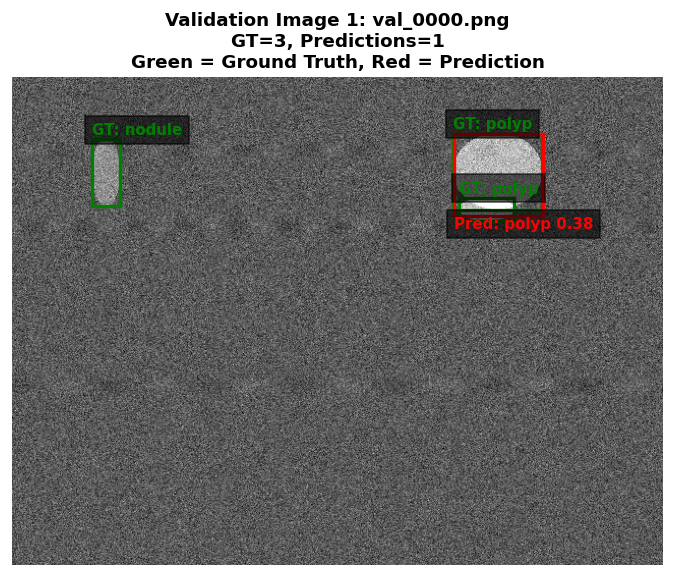

Image 1: val_0000.png


In [ ]:

# ============================================================
# Task 2: Visualize 10 Validation Images + Manual TP/FP/FN
# ============================================================

if model is not None:
    try:
        # Load fine-tuned model if available
        best_model_path = '/content/yolo_training/medical_detection/weights/best.pt'
        if os.path.exists(best_model_path):
            eval_model = YOLO(best_model_path)
            print("Loaded fine-tuned model.")
        else:
            eval_model = model
            print("Fine-tuned model not found. Using current model.")

        val_img_dir = os.path.join(DATASET_DIR, 'images', 'val')
        val_label_dir = os.path.join(DATASET_DIR, 'labels', 'val')

        val_images = sorted(os.listdir(val_img_dir))[:10]

        total_TP = 0
        total_FP = 0
        total_FN = 0

        label_names = {0: 'polyp', 1: 'nodule'}

        def yolo_to_xyxy(label_line, img_w, img_h):
            parts = label_line.strip().split()
            cls_id = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:])

            x1 = (xc - bw / 2) * img_w
            y1 = (yc - bh / 2) * img_h
            x2 = (xc + bw / 2) * img_w
            y2 = (yc + bh / 2) * img_h

            return cls_id, x1, y1, x2, y2

        for idx, img_file in enumerate(val_images):
            img_path = os.path.join(val_img_dir, img_file)
            label_file = img_file.replace('.png', '.txt')
            label_path = os.path.join(val_label_dir, label_file)

            img = np.array(Image.open(img_path))
            h, w = img.shape[:2]

            results = eval_model.predict(img_path, conf=0.25, verbose=False)
            result = results[0]

            plt.figure(figsize=(7, 7))
            plt.imshow(img[:, :, 0], cmap='gray')
            ax = plt.gca()

            # ----------------------------
            # Draw ground truth boxes: green
            # ----------------------------
            gt_count = 0
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    cls_id, x1, y1, x2, y2 = yolo_to_xyxy(line, w, h)
                    gt_count += 1

                    rect = patches.Rectangle(
                        (x1, y1),
                        x2 - x1,
                        y2 - y1,
                        linewidth=2,
                        edgecolor='green',
                        facecolor='none'
                    )
                    ax.add_patch(rect)

                    ax.text(
                        x1, y1 - 5,
                        f"GT: {label_names[cls_id]}",
                        color='green',
                        fontsize=9,
                        fontweight='bold',
                        bbox=dict(facecolor='black', alpha=0.6)
                    )

            # ----------------------------
            # Draw prediction boxes: red
            # ----------------------------
            pred_count = len(result.boxes)

            if pred_count > 0:
                for j in range(pred_count):
                    xyxy = result.boxes.xyxy[j].cpu().numpy()
                    conf = float(result.boxes.conf[j].cpu().numpy())
                    cls_id = int(result.boxes.cls[j].cpu().numpy())

                    x1, y1, x2, y2 = xyxy

                    rect = patches.Rectangle(
                        (x1, y1),
                        x2 - x1,
                        y2 - y1,
                        linewidth=2,
                        edgecolor='red',
                        facecolor='none'
                    )
                    ax.add_patch(rect)

                    ax.text(
                        x1, y2 + 12,
                        f"Pred: {label_names.get(cls_id, cls_id)} {conf:.2f}",
                        color='red',
                        fontsize=9,
                        fontweight='bold',
                        bbox=dict(facecolor='black', alpha=0.6)
                    )

            plt.title(
                f"Validation Image {idx + 1}: {img_file}\n"
                f"GT={gt_count}, Predictions={pred_count}\n"
                f"Green = Ground Truth, Red = Prediction",
                fontsize=11,
                fontweight='bold'
            )
            plt.axis('off')
            plt.show()

            print(f"Image {idx + 1}: {img_file}")
            tp = int(input("Manually count TP: "))
            fp = int(input("Manually count FP: "))
            fn = int(input("Manually count FN: "))

            total_TP += tp
            total_FP += fp
            total_FN += fn

            print("-" * 50)

        precision = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0
        recall = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0

        print("Overall Detection Results")
        print("=" * 50)
        print(f"Total TP = {total_TP}")
        print(f"Total FP = {total_FP}")
        print(f"Total FN = {total_FN}")
        print(f"Precision = {precision:.3f}")
        print(f"Recall    = {recall:.3f}")

    except Exception as e:
        print(f"Error: {e}")

else:
    print("Model not loaded. Run Section 4 first.")

In [ ]:
# ============================================================
# Task 3: YOLOv8n vs YOLOv8s
# ============================================================

if model is not None:
    print("Task 3: YOLOv8n vs YOLOv8s")
    print("=" * 60)

    import time

    device_used = 0 if torch.cuda.is_available() else 'cpu'
    print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

    # ------------------------------------------------------------
    # 1. Load YOLOv8n and YOLOv8s
    # ------------------------------------------------------------
    yolo_n = YOLO('yolov8n.pt')
    yolo_s = YOLO('yolov8s.pt')

    models_to_compare = {
        "YOLOv8n": yolo_n,
        "YOLOv8s": yolo_s
    }

    # ------------------------------------------------------------
    # 2. Use the same validation images
    # ------------------------------------------------------------
    val_img_dir = os.path.join(DATASET_DIR, 'images', 'val')
    val_images = sorted(os.listdir(val_img_dir))[:10]
    val_img_paths = [os.path.join(val_img_dir, img) for img in val_images]

    speed_results = {}
    map50_results = {}
    map_results = {}

    # ------------------------------------------------------------
    # 3. Measure inference time
    # ------------------------------------------------------------
    for model_name, yolo_model in models_to_compare.items():
        print()
        print(f"Testing {model_name}...")
        print("-" * 40)

        # Warm-up
        for img_path in val_img_paths[:3]:
            _ = yolo_model.predict(
                img_path,
                conf=0.25,
                imgsz=640,
                device=device_used,
                verbose=False
            )

        times = []

        for img_path in val_img_paths:
            start = time.time()

            _ = yolo_model.predict(
                img_path,
                conf=0.25,
                imgsz=640,
                device=device_used,
                verbose=False
            )

            end = time.time()
            times.append((end - start) * 1000)

        avg_time = np.mean(times)
        fps = 1000 / avg_time

        speed_results[model_name] = fps

        print(f"Average inference time: {avg_time:.2f} ms/image")
        print(f"FPS: {fps:.2f}")

    # ------------------------------------------------------------
    # 4. Compare mAP
    # ------------------------------------------------------------
    print()
    print("Validation mAP Comparison")
    print("=" * 60)

    for model_name, yolo_model in models_to_compare.items():
        try:
            val_results = yolo_model.val(
                data=yaml_path,
                imgsz=640,
                device=device_used,
                verbose=False
            )

            map50_results[model_name] = val_results.box.map50
            map_results[model_name] = val_results.box.map

            print(f"{model_name}")
            print(f"  mAP@0.5:      {val_results.box.map50:.4f}")
            print(f"  mAP@0.5:0.95: {val_results.box.map:.4f}")

        except Exception as e:
            print(f"{model_name} validation failed: {e}")
            map50_results[model_name] = 0
            map_results[model_name] = 0

    # ------------------------------------------------------------
    # 5. Summary table
    # ------------------------------------------------------------
    print()
    print("Summary")
    print("=" * 60)
    print(f"{'Model':<10} {'FPS':>10} {'mAP@0.5':>12} {'mAP@0.5:0.95':>15}")
    print("-" * 60)

    for model_name in models_to_compare.keys():
        print(
            f"{model_name:<10} "
            f"{speed_results[model_name]:>10.2f} "
            f"{map50_results[model_name]:>12.4f} "
            f"{map_results[model_name]:>15.4f}"
        )

    # ------------------------------------------------------------
    # 6. Plot speed vs accuracy trade-off
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 6))

    for model_name in models_to_compare.keys():
        ax.scatter(
            speed_results[model_name],
            map50_results[model_name],
            s=180,
            label=model_name
        )

        ax.text(
            speed_results[model_name] + 0.5,
            map50_results[model_name],
            model_name,
            fontsize=12,
            fontweight='bold'
        )

    ax.set_xlabel("Speed (FPS)", fontsize=12)
    ax.set_ylabel("Accuracy (mAP@0.5)", fontsize=12)
    ax.set_title("YOLOv8 Speed vs Accuracy Trade-off", fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()

    print()
    print("Interpretation:")
    print("- YOLOv8n is usually faster but less accurate.")
    print("- YOLOv8s is usually slower but may give better accuracy.")
    print("- For real-time polyp detection, choose the model that keeps high recall while maintaining real-time FPS.")

else:
    print("Model not loaded. Run Section 4 first.")

In [ ]:
# ============================================================
# Task 4: Non-Maximum Suppression from Scratch (Starter Code)
# ============================================================

import torch
from torchvision.ops import nms

def nms_from_scratch(boxes, scores, iou_threshold=0.5):
    """
    Non-Maximum Suppression (NMS) implementation from scratch.

    Algorithm:
    1. Sort all boxes by confidence score (descending)
    2. Pick the box with highest confidence -> add to results
    3. Remove all boxes that overlap with it above IoU threshold
    4. Repeat until no boxes remain

    Args:
        boxes: list of [x1, y1, x2, y2]
        scores: list of confidence scores
        iou_threshold: IoU threshold for suppression

    Returns: indices of kept boxes
    """
    if len(boxes) == 0:
        return []

    # Sort by confidence (descending)
    sorted_indices = np.argsort(-np.array(scores))
    keep = []

    while len(sorted_indices) > 0:
        # Keep the highest confidence box
        current = sorted_indices[0]
        keep.append(current)

        # Compare with remaining boxes
        remaining = sorted_indices[1:]
        remove = []

        for i, idx in enumerate(remaining):
            iou = compute_iou(boxes[current], boxes[idx])
            if iou >= iou_threshold:
                remove.append(i)

        # Remove overlapping boxes
        sorted_indices = np.delete(remaining, remove)

    return keep


# Test NMS
test_boxes = [
    [100, 100, 250, 250],  # Box A (highest confidence)
    [110, 105, 260, 255],  # Box B (overlaps A heavily)
    [105, 108, 255, 252],  # Box C (overlaps A heavily)
    [400, 300, 550, 450],  # Box D (no overlap with A)
    [410, 310, 560, 460],  # Box E (overlaps D)
]
test_scores = [0.95, 0.88, 0.82, 0.90, 0.75]

kept = nms_from_scratch(test_boxes, test_scores, iou_threshold=0.5)
print("Non-Maximum Suppression Results")
print("=" * 50)
print(f"Input: {len(test_boxes)} boxes")
print(f"Output: {len(kept)} boxes (after NMS)")
print()
for i, idx in enumerate(kept):
    print(f"  Kept box {idx}: score={test_scores[idx]:.2f}, coords={test_boxes[idx]}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before NMS
ax = axes[0]
ax.set_xlim(0, 650)
ax.set_ylim(550, 0)
colors_nms = ['#E74C3C', '#3498DB', '#2ECC71', '#E67E22', '#9B59B6']
for i, (box, score) in enumerate(zip(test_boxes, test_scores)):
    rect = patches.Rectangle(
        (box[0], box[1]), box[2]-box[0], box[3]-box[1],
        linewidth=2, edgecolor=colors_nms[i], facecolor=colors_nms[i], alpha=0.3
    )
    ax.add_patch(rect)
    ax.text(box[0], box[1]-5, f"Box {i}: {score:.2f}",
            color=colors_nms[i], fontsize=9, fontweight='bold')
ax.set_title(f"Before NMS ({len(test_boxes)} boxes)", fontsize=13, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)

# After NMS
ax = axes[1]
ax.set_xlim(0, 650)
ax.set_ylim(550, 0)
for idx in kept:
    box = test_boxes[idx]
    rect = patches.Rectangle(
        (box[0], box[1]), box[2]-box[0], box[3]-box[1],
        linewidth=3, edgecolor=colors_nms[idx], facecolor=colors_nms[idx], alpha=0.3
    )
    ax.add_patch(rect)
    ax.text(box[0], box[1]-5, f"Box {idx}: {test_scores[idx]:.2f}",
            color=colors_nms[idx], fontsize=9, fontweight='bold')
ax.set_title(f"After NMS ({len(kept)} boxes)", fontsize=13, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)

plt.suptitle("Non-Maximum Suppression: Remove Redundant Overlapping Detections",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print()
print("Without NMS: the AI draws 3 boxes around one polyp.")
print("With NMS: only the highest-confidence box survives.")
print("Like a senior radiologist resolving conflicting readings.")


boxes_tensor = torch.tensor(test_boxes, dtype=torch.float32)
scores_tensor = torch.tensor(test_scores, dtype=torch.float32)

torchvision_kept = nms(
    boxes_tensor,
    scores_tensor,
    iou_threshold=0.5
)

torchvision_kept = torchvision_kept.numpy().tolist()

print()
print("Compare with torchvision.ops.nms()")
print("=" * 50)
print(f"My NMS kept indices:        {kept}")
print(f"Torchvision kept indices:  {torchvision_kept}")

if kept == torchvision_kept:
    print("Result: Match! My NMS gives the same output as torchvision.ops.nms().")
else:
    print("Result: Different output. Check IoU calculation or sorting behavior.")

In [ ]:
# ============================================================
# Task 5: Data Augmentation Experiment
# ============================================================

print("Task 5: Data Augmentation Experiment")
print("=" * 60)

device_used = 0 if torch.cuda.is_available() else 'cpu'

# ------------------------------------------------------------
# 1. Train baseline model: without augmentation
# ------------------------------------------------------------
print("Training baseline model without strong augmentation...")

baseline_model = YOLO('yolov8n.pt')

baseline_results = baseline_model.train(
    data=yaml_path,
    epochs=10,
    imgsz=640,
    batch=8,
    device=device_used,
    project='/content/yolo_aug_experiment',
    name='baseline_no_aug',
    exist_ok=True,

    # Disable / reduce augmentation
    mosaic=0.0,
    mixup=0.0,
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.0
)

baseline_val = baseline_model.val(
    data=yaml_path,
    imgsz=640,
    device=device_used,
    verbose=False
)

baseline_map50 = baseline_val.box.map50
baseline_map = baseline_val.box.map

print(f"Baseline mAP@0.5: {baseline_map50:.4f}")
print(f"Baseline mAP@0.5:0.95: {baseline_map:.4f}")


# ------------------------------------------------------------
# 2. Train augmented model
# ------------------------------------------------------------
print()
print("Training model with data augmentation...")

aug_model = YOLO('yolov8n.pt')

aug_results = aug_model.train(
    data=yaml_path,
    epochs=10,
    imgsz=640,
    batch=8,
    device=device_used,
    project='/content/yolo_aug_experiment',
    name='with_augmentation',
    exist_ok=True,

    # Required augmentations
    mosaic=1.0,
    mixup=0.3,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4
)

aug_val = aug_model.val(
    data=yaml_path,
    imgsz=640,
    device=device_used,
    verbose=False
)

aug_map50 = aug_val.box.map50
aug_map = aug_val.box.map

print(f"Augmented mAP@0.5: {aug_map50:.4f}")
print(f"Augmented mAP@0.5:0.95: {aug_map:.4f}")


# ------------------------------------------------------------
# 3. Compare results
# ------------------------------------------------------------
print()
print("Data Augmentation Comparison")
print("=" * 60)
print(f"{'Model':<25} {'mAP@0.5':>12} {'mAP@0.5:0.95':>15}")
print("-" * 60)
print(f"{'Without Augmentation':<25} {baseline_map50:>12.4f} {baseline_map:>15.4f}")
print(f"{'With Augmentation':<25} {aug_map50:>12.4f} {aug_map:>15.4f}")

diff_map50 = aug_map50 - baseline_map50
diff_map = aug_map - baseline_map

print()
print(f"mAP@0.5 improvement: {diff_map50:+.4f}")
print(f"mAP@0.5:0.95 improvement: {diff_map:+.4f}")


# ------------------------------------------------------------
# 4. Plot mAP comparison
# ------------------------------------------------------------
labels = ['Without Aug', 'With Aug']
map50_values = [baseline_map50, aug_map50]
map_values = [baseline_map, aug_map]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, map50_values, width, label='mAP@0.5')
ax.bar(x + width/2, map_values, width, label='mAP@0.5:0.95')

ax.set_ylabel('mAP')
ax.set_title('Effect of Data Augmentation on YOLOv8 Performance',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(map50_values):
    ax.text(i - width/2, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

for i, v in enumerate(map_values):
    ax.text(i + width/2, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Interpretation
# ------------------------------------------------------------
print()
print("Interpretation:")
if diff_map50 > 0:
    print("- Data augmentation improved mAP@0.5.")
else:
    print("- Data augmentation did not improve mAP@0.5 in this run.")

if diff_map > 0:
    print("- Data augmentation improved stricter mAP@0.5:0.95.")
else:
    print("- Data augmentation did not improve stricter mAP@0.5:0.95 in this run.")

print("- Mosaic helps the model see objects in different contexts.")
print("- MixUp combines images and labels, improving robustness.")
print("- HSV jitter changes color/brightness, helping generalization.")

## 9. Gemini AI Exercise

Use Gemini AI as a **detection architecture consultant** — asking about
YOLO's mechanisms, detector selection for clinical tasks, and interpreting
detection metrics.

The three prompts cover key decisions in medical object detection:
1. **How does YOLO work?** (grid cells, bounding box prediction)
2. **Which detector for my task?** (Faster R-CNN vs YOLO for lung nodules)
3. **What do my metrics mean?** (mAP@0.5 vs mAP@0.5:0.95 gap)


In [ ]:
# ============================================================
# Section 9: Gemini AI Exercise
# ============================================================

# --- Prompt 1: YOLO Grid Cell Mechanism ---
prompt_1 = (
    "Explain how YOLO divides an image into grid cells and predicts "
    "bounding boxes. Use a colonoscopy polyp detection analogy where "
    "different cells monitor different regions of the colon image."
)

# --- Prompt 2: Detector Selection for Clinical Task ---
prompt_2 = (
    "I'm choosing between Faster R-CNN and YOLOv8 for detecting lung "
    "nodules in chest X-rays. The nodules are small (5-15mm) and accuracy "
    "is more important than speed. Which should I use and why?"
)

# --- Prompt 3: Interpreting Detection Metrics ---
prompt_3 = (
    "My YOLOv8 polyp detector achieves 85% mAP@0.5 but only 60% "
    "mAP@0.5:0.95. What does this gap mean clinically, and how can "
    "I improve localization precision?"
)

try:
    from google.colab import ai

    print("Prompt 1: YOLO Grid Cell Mechanism")
    print("=" * 60)
    response_1 = ai.generate_text(prompt_1)
    print(response_1)

    print()
    print("Prompt 2: Detector Selection for Clinical Task")
    print("=" * 60)
    response_2 = ai.generate_text(prompt_2)
    print(response_2)

    print()
    print("Prompt 3: Interpreting Detection Metrics")
    print("=" * 60)
    response_3 = ai.generate_text(prompt_3)
    print(response_3)

except ImportError:
    print("Gemini AI not available (not running in Google Colab).")
    print("To use Gemini, run this notebook in Google Colab.")
    print()
    print("Prompts to try when you have access:")
    print()
    print(f"Prompt 1: {prompt_1}")
    print()
    print(f"Prompt 2: {prompt_2}")
    print()
    print(f"Prompt 3: {prompt_3}")
    print()
    print("Learning goal: Use AI as a detection architecture consultant --")
    print("asking about speed-accuracy trade-offs, clinical requirements,")
    print("and model optimization strategies for medical detection tasks.")


## 10. Bonus: Faster R-CNN Comparison

To appreciate YOLO's speed advantage, let's compare it with **Faster R-CNN**
from `torchvision`. Faster R-CNN is a two-stage detector:
1. **Stage 1 (RPN):** Propose regions of interest
2. **Stage 2:** Classify each region and refine bounding boxes

Faster R-CNN typically achieves **higher accuracy on small objects** but at
the cost of inference speed. This trade-off is central to choosing a detector
for clinical applications.

> **The question:** For colonoscopy polyp detection at 30 FPS, is Faster R-CNN
> fast enough? Or do we need YOLO's speed?


In [ ]:
# ============================================================
# Section 10: Bonus — Faster R-CNN from torchvision
# ============================================================

try:
    from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

    # Load pretrained Faster R-CNN
    print("Loading Faster R-CNN (ResNet-50 + FPN)...")
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    frcnn_model = fasterrcnn_resnet50_fpn(weights=weights)
    frcnn_model.eval()
    frcnn_model.to(device)
    print("Faster R-CNN loaded successfully!")
    print(f"  Backbone: ResNet-50 with FPN")
    print(f"  Classes: {len(weights.meta['categories'])} (COCO)")
    print()

    # Prepare a test image
    test_img_np = test_images[0]
    transform = transforms.Compose([transforms.ToTensor()])
    test_tensor = transform(test_img_np).to(device)

    # Run inference
    with torch.no_grad():
        frcnn_results = frcnn_model([test_tensor])[0]

    n_det = len(frcnn_results['boxes'])
    print(f"Faster R-CNN detections: {n_det}")
    if n_det > 0:
        print(f"  Classes: {frcnn_results['labels'][:5].cpu().numpy()}")
        print(f"  Scores: {frcnn_results['scores'][:5].cpu().numpy().round(3)}")

except Exception as e:
    print(f"Could not load Faster R-CNN: {e}")
    frcnn_model = None


In [ ]:
# --- Speed comparison: YOLOv8 vs Faster R-CNN ---
print("Speed Comparison: YOLOv8n vs Faster R-CNN")
print("=" * 50)

speed_results = {}

# YOLOv8 timing
if model is not None:
    test_pil = Image.fromarray(test_images[0])
    # Warm-up
    for _ in range(3):
        _ = model.predict(test_pil, verbose=False)
    # Timed runs
    yolo_times = []
    for _ in range(10):
        start = time.time()
        _ = model.predict(test_pil, verbose=False)
        yolo_times.append((time.time() - start) * 1000)
    speed_results['YOLOv8n'] = np.mean(yolo_times)
    print(f"  YOLOv8n:      {speed_results['YOLOv8n']:.1f} ms ({1000/speed_results['YOLOv8n']:.1f} FPS)")

# Faster R-CNN timing
try:
    if frcnn_model is not None:
        test_tensor_speed = transform(test_images[0]).to(device)
        # Warm-up
        for _ in range(3):
            with torch.no_grad():
                _ = frcnn_model([test_tensor_speed])
        # Timed runs
        frcnn_times = []
        for _ in range(10):
            start = time.time()
            with torch.no_grad():
                _ = frcnn_model([test_tensor_speed])
            frcnn_times.append((time.time() - start) * 1000)
        speed_results['Faster R-CNN'] = np.mean(frcnn_times)
        print(f"  Faster R-CNN: {speed_results['Faster R-CNN']:.1f} ms ({1000/speed_results['Faster R-CNN']:.1f} FPS)")
except Exception:
    pass

# Visualize speed comparison
if len(speed_results) >= 2:
    fig, ax = plt.subplots(figsize=(8, 5))
    models_list = list(speed_results.keys())
    times_list = list(speed_results.values())
    fps_list = [1000 / t for t in times_list]
    colors_bar = ['#3498DB', '#E74C3C']

    bars = ax.bar(models_list, fps_list, color=colors_bar[:len(models_list)],
                  alpha=0.8, width=0.5)
    ax.axhline(y=30, color='green', linestyle='--', linewidth=2,
               label='30 FPS (real-time colonoscopy)')
    ax.set_ylabel("Frames Per Second (FPS)", fontsize=12)
    ax.set_title("Inference Speed: YOLOv8 vs Faster R-CNN",
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, fps_val in zip(bars, fps_list):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{fps_val:.1f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    if 'YOLOv8n' in speed_results and 'Faster R-CNN' in speed_results:
        speedup = speed_results['Faster R-CNN'] / speed_results['YOLOv8n']
        print(f"\nYOLOv8n is {speedup:.1f}x faster than Faster R-CNN")
        print("For real-time colonoscopy at 30 FPS:")
        yolo_fps = 1000 / speed_results['YOLOv8n']
        frcnn_fps = 1000 / speed_results['Faster R-CNN']
        print(f"  YOLOv8n: {'YES' if yolo_fps >= 30 else 'NO'} ({yolo_fps:.0f} FPS)")
        print(f"  Faster R-CNN: {'YES' if frcnn_fps >= 30 else 'NO'} ({frcnn_fps:.0f} FPS)")
elif len(speed_results) == 1:
    model_name = list(speed_results.keys())[0]
    fps_val = 1000 / speed_results[model_name]
    print(f"\n{model_name}: {fps_val:.1f} FPS")
    print("(Could not load Faster R-CNN for comparison)")
else:
    print("\nNo models available for speed comparison.")
    print("Expected results (from literature):")
    print("  YOLOv8n: ~100-300 FPS (GPU), ~10-30 FPS (CPU)")
    print("  Faster R-CNN: ~5-20 FPS (GPU), ~1-3 FPS (CPU)")
    print("  YOLOv8 is typically 5-30x faster than Faster R-CNN")


## 11. Summary and Self-Check

### Returning to Our Patient

The 58-year-old patient's colonoscopy is complete. The AI overlay flagged
**4 polyps** — including the flat 6mm lesion hidden behind a mucosal fold.
The gastroenterologist confirms and removes all four. Without AI, at least
one would have been missed.

That missed polyp? It was an **advanced adenoma**. Detection today prevented
cancer tomorrow. The technology behind this: **object detection** — the same
AI that lets autonomous cars see pedestrians, adapted to save lives inside
the human body.

The algorithms we practiced today — IoU for measuring localization accuracy,
precision-recall for evaluating detection quality, YOLO for real-time inference
— are the same tools powering FDA-cleared devices in endoscopy suites worldwide.

### Key Takeaways (Matching Slide S73)

1. **Classification vs localization vs detection:** Classification says "polyp present." Detection says "polyp at position (234, 156), size 18x22, confidence 0.94."
2. **IoU, mAP, precision-recall:** The metrics that quantify detection quality. IoU > 0.5 = correct detection. mAP averages across classes and thresholds.
3. **R-CNN family evolution:** R-CNN (49s) -> Fast R-CNN (shared features) -> Faster R-CNN (learned proposals, 0.2s). Each architecture solves the previous bottleneck.
4. **YOLO single-stage paradigm:** One forward pass, grid cell predictions, real-time speed. YOLOv8: anchor-free, 52.8% mAP on COCO at 60 FPS.
5. **Anchor-free and NMS-free:** Modern simplifications (YOLOv8, YOLOv10) eliminate hand-designed components.
6. **Clinical deployment:** Polyp detection (7% miss rate vs 22-28%), surgical tools, pathology, lung nodules — each clinical context determines the right detector.

### Key Numbers (Matching Slide S74)

| Number | Significance |
|--------|-------------|
| 22-28% | Polyp miss rate without AI assistance |
| 545 FPS | YOLOv8 with TensorRT optimization |
| 88.3% mAP | EndoSight AI polyp detection performance |
| 95% accuracy | Faster R-CNN brain tumor detection (IoU > 0.7) |
| 14-30% | ADR improvement with AI-assisted colonoscopy |
| 99.17% | Maximum precision in YOLO medical imaging systematic review |

### Self-Check Checklist

- [ ] I can explain the difference between classification, localization, and detection
- [ ] I implemented `compute_iou()` and understand how IoU measures localization quality
- [ ] I computed precision, recall, and AP at different IoU thresholds
- [ ] I loaded a pretrained YOLOv8 model and ran inference on images
- [ ] I understand the YOLO dataset format (normalized x_center, y_center, width, height)
- [ ] I prepared a dataset and fine-tuned YOLOv8 with transfer learning
- [ ] I evaluated detection performance using mAP@0.5 and mAP@0.5:0.95
- [ ] I compared YOLO's speed with Faster R-CNN and understand the speed-accuracy trade-off
- [ ] I implemented NMS from scratch and understand why it is needed
- [ ] I can explain when to choose YOLO vs Faster R-CNN for a clinical detection task

### Next Week Preview

**Week 13: LLM and RAG — Clinical AI Assistants**
- This week: **VISUAL AI** that detects objects in images
- Next week: **LANGUAGE AI** that understands clinical text
- Clinical scenario: A resident at 3 AM gets a rare case. What if an AI
  assistant could search the latest literature and cross-reference clinical
  guidelines instantly?
- Week 13 introduces Large Language Models (LLMs) and Retrieval-Augmented
  Generation (RAG) — imagine an AI that reads radiology reports, finds
  relevant literature, and answers clinical questions at 3 AM.
- Prepare: Think about how AI could help with clinical documentation.


In [ ]:
# ============================================================
# Final Verification
# ============================================================
print("=" * 65)
print("Congratulations! You have completed the Week 12 Notebook!")
print("Object Detection: From R-CNN to YOLO")
print("=" * 65)

print()
print("Detection Fundamentals Covered:")
print("  1. Bounding box representation (xyxy and YOLO xywh formats)")
print("  2. IoU computation and visualization")
print("  3. Precision-recall curves and Average Precision (AP)")
print("  4. Non-Maximum Suppression (NMS)")

print()
print("YOLO in Action:")
print("  5. YOLOv8 model loading and architecture exploration")
print("  6. Running inference and parsing detection results")
print("  7. Synthetic medical dataset creation (YOLO format)")
print("  8. Fine-tuning with transfer learning")
print("  9. Evaluation: mAP@0.5, mAP@0.5:0.95, per-class metrics")

print()
print("Comparisons:")
print("  10. YOLOv8 vs Faster R-CNN speed benchmark")
print("  11. Confidence threshold analysis")
print("  12. Custom NMS vs built-in NMS")

print()
print("Visualizations Produced:")
print("  1. Synthetic medical images with ground truth boxes")
print("  2. IoU overlap visualization (4 scenarios)")
print("  3. IoU sensitivity to box displacement")
print("  4. Precision-recall curves at multiple IoU thresholds")
print("  5. AP bar chart across IoU thresholds")
print("  6. Dataset samples with annotations")
print("  7. YOLOv8 inference results")
print("  8. Validation set predictions")
print("  9. NMS before/after visualization")
print("  10. Speed comparison bar chart")

print()
print("Returning to the endoscopy suite:")
print("  The 58-year-old patient's colonoscopy found 4 polyps --")
print("  including the flat 6mm lesion behind the fold. Without AI,")
print("  it would have been missed. That adenoma would have grown")
print("  into cancer over the next 3-10 years.")
print()
print("  Object detection does not replace the gastroenterologist.")
print("  It gives them superhuman peripheral vision -- catching what")
print("  fatigue, folds, and flat morphology would otherwise hide.")
print()
print("  Next week: From VISUAL AI to LANGUAGE AI.")
print("  LLMs and RAG help residents find answers at 3 AM --")
print("  the same AI revolution, applied to clinical text.")
